In [74]:
import numpy as np
import obspy
import emd
import pandas as pd
from tqdm.notebook import tqdm
import os
import scipy.signal as sg
from concurrent.futures import ThreadPoolExecutor
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import clear_output
from torchinfo import summary
import librosa


In [75]:
#Comprobamos que CUDA esté corriendo correctamente en nuestra pc
print("CUDA Available: ", torch.cuda.is_available())
print("CUDA Version: ", torch.version.cuda)
print("Device Count: ", torch.cuda.device_count())

CUDA Available:  True
CUDA Version:  12.4
Device Count:  1


<h1>DISEÑO DE LOS FILTROS<h1>

In [76]:
# Función de filtro pasa-banda utilizando el diseño de filtro Butterworth.
# Filtra los datos entre las frecuencias lowc y high.
def butter_bandpass_filter(senal: np.array, lowcut: float, highcut: float, fs: float, order: int):
    nyquist = 0.5 * fs  # Frecuencia de Nyquist, la mitad de la tasa de muestreo
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sg.butter(order, [low, high], btype='band', analog=False)  # Diseña el filtro pasa-banda Butterworth
    y = sg.filtfilt(b, a, senal)  # Aplica el filtro a los datos usando filtrado cero-fase
    return y

In [77]:
def notch_filter(senal, fs, f0, Q):
    """
    senal : array-like
        La señal de entrada a la que se le aplicará el filtro.
    fs : float
        Frecuencia de muestreo de la señal (en Hz).
    f0 : float
        Frecuencia central que se desea eliminar (en Hz).
    Q : float
        Factor de calidad del filtro notch.
    Retorna:
    --------
    senal_filtrada : array-like
        La señal después de aplicar el filtro notch.
    """
    # Diseñar el filtro notch
    b, a = sg.iirnotch(f0, Q, fs)

    # Aplicar el filtro a la señal
    senal_filtrada = sg.lfilter(b, a, senal)

    return senal_filtrada

In [78]:
# Ruta de la carpeta donde están los archivos de audio
folder_path = "./Respiratory_Sound_Database\Respiratory_Sound_Database//audio_and_txt_files"
# Obtener lista de archivos de audio en la carpeta
audio_files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]

audio_path = os.path.join(folder_path, audio_files[7])

In [79]:
#DATOS ORIGINALES 

audio, sr = librosa.load(audio_path, sr=None)  # sr=None para mantener la tasa de muestreo original
time = np.arange(len(audio))/sr

In [80]:
sr

4000

In [81]:
#DATOS CON FILTRO PASABANDA
"""Las señales de respiración humana suelen contener información útil en el rango de 100 Hz a 2000 Hz.

Frecuencias bajas (100 Hz): Las respiraciones normales tienen componentes de baja frecuencia que representan el flujo de aire en los pulmones.

Frecuencias altas (2000 Hz): Algunos sonidos respiratorios, como sibilancias o crepitaciones, pueden tener componentes de mayor frecuencia.

Las frecuencias fuera de este rango suelen ser ruido no deseado:

Ruido de baja frecuencia (<100 Hz): Puede ser causado por movimientos del cuerpo, vibraciones o interferencias.

Ruido de alta frecuencia (>2000 Hz): Puede ser causado por ruido ambiental, como el zumbido de equipos eléctricos. """

audiof1 = butter_bandpass_filter(audio, 100, 1800, sr, 4)

In [82]:
#DATOS CON FILTRO NOTCH
"""50 Hz: Es la frecuencia de la red eléctrica en Portugal y Grecia (los países donde se creó la base de datos)."""
audiof2 = notch_filter(audiof1, sr, 50, 35)

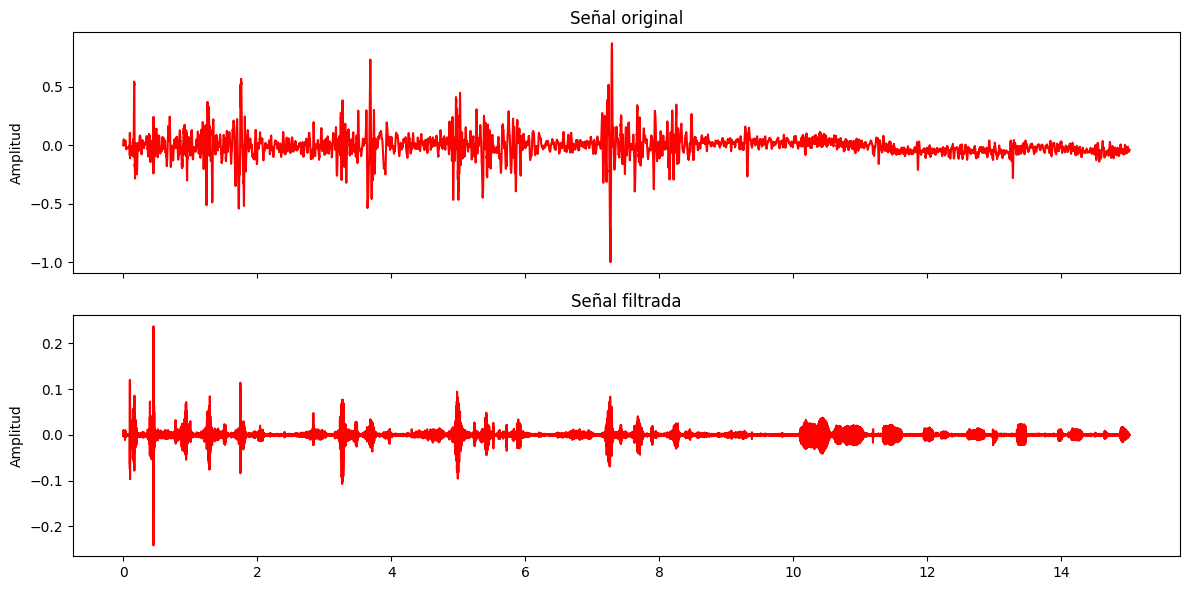

In [84]:
# Graficar las formas de onda
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Gráfico de señal original
ax[0].plot(time, audio, color='red')
ax[0].set_title("Señal original")
ax[0].set_ylabel("Amplitud")

# Gráfico de señal después de los filtros
ax[1].plot(time, audiof2, color='red')
ax[1].set_title("Señal filtrada")
ax[1].set_ylabel("Amplitud")


plt.tight_layout()  
plt.show()

<h1>EXTRACCIÓN DE CARACTERÍSTICAS<h1>

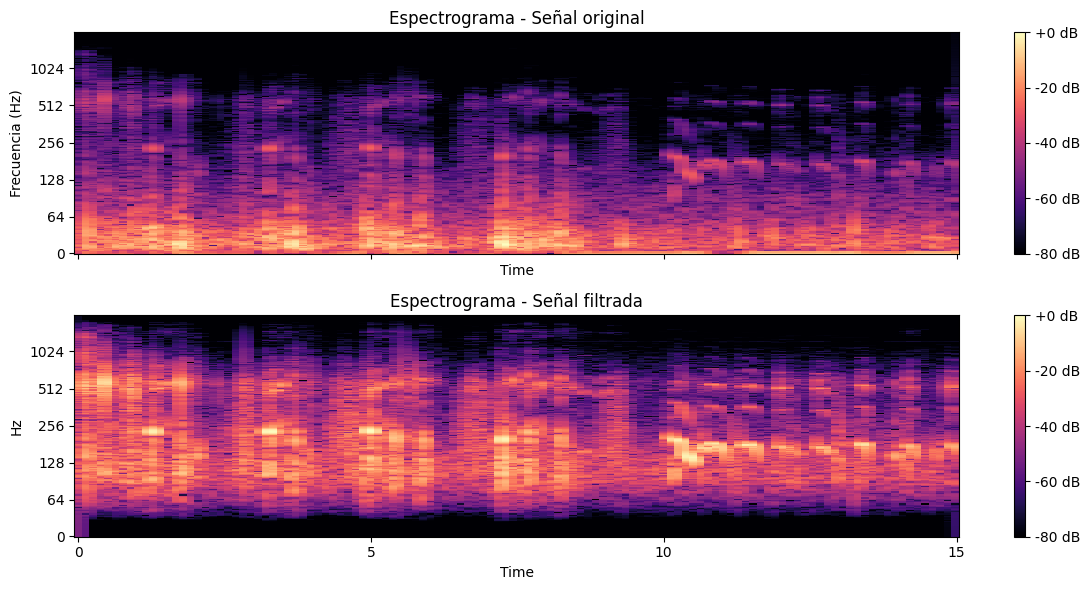

In [85]:
# Calcular espectrogramas
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
Df = librosa.amplitude_to_db(np.abs(librosa.stft(audiof2)), ref=np.max)

# Crear la figura con dos subgráficos
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Espectrograma para persona enferma
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax[0])
ax[0].set_title("Espectrograma - Señal original")
ax[0].set_ylabel("Frecuencia (Hz)")
fig.colorbar(librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log'), ax=ax[0], format='%+2.0f dB')

# Espectrograma para persona sana
librosa.display.specshow(Df, sr=sr, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set_title("Espectrograma - Señal filtrada")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Frecuencia (Hz)")
fig.colorbar(librosa.display.specshow(Df, sr=sr, x_axis='time', y_axis='log'), ax=ax[1], format='%+2.0f dB')

plt.tight_layout()  
plt.show()